In [1]:
import sys
import os
 
# Obtener la ruta absoluta del directorio padre
sys.path.append('../')
import torch
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
from seaborn import heatmap
from Utils.train import  patient_stratify_split, cv_patients

from skorch.callbacks import LRScheduler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from braindecode import EEGClassifier
from braindecode.models.util import models_dict
from braindecode.models import Labram, EEGPT, BENDR, CBraMod, EEGNet
from braindecode.util import set_random_seeds
from braindecode.datautil import infer_signal_properties
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc



models=list(models_dict.keys())
# Set random seed to ensure reproducible initialization below
seed = 2024
cuda = torch.cuda.is_available()
set_random_seeds(seed=seed, cuda=cuda)

In [2]:
channels=['Fp1', 'Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
channels_dif=['Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F7-T3', 'T3-T5', 'T5-O1', 'F8-T4', 'T4-T6', 'T6-O2', 'Fz-Cz', 'Cz-Pz']
path_demographic="../d/data_patients.csv"

### Data base demographic
df_demog=pd.read_csv(path_demographic, sep="," )
df_demog["numeric_outcome"]=df_demog["Outcome"].map({"Good": 1, "Poor": 0})
df_demog.reset_index(drop=True, inplace=True)
df_demog.head()

,Id_Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC,numeric_outcome
0,284,A,53.0,Male,NaN,True,True,33.0,Good,1,1
1,286,F,85.0,Female,7.0,False,False,NaN,Good,1,1
2,296,A,48.0,Male,NaN,True,True,36.0,Good,1,1
3,299,A,45.0,Male,NaN,True,True,33.0,Good,1,1
4,303,D,51.0,Male,24.0,True,True,33.0,Good,1,1


In [3]:
23040-128*90

11520

In [4]:
path_files="../raw_tif/"
hours=[ 36, 44 ]
hour_list = os.listdir(path_files)
hour_list = [x for x in hour_list if int(x.split("h")[1]) in hours]
Raws=[]
Patients=[]
# Carga Pre-Launch de MNE asegurándose que la RAM los acople sin retrasos lazy (preload=True)
for h in hour_list:
    print(h)
    file_list = os.listdir(path_files+h+"/")
    Raws += [mne.io.read_raw_fif(path_files+h+"/"+file, preload=True, verbose=0) for file in file_list]
    Patients += [file.split(".")[0][-4:] for file in file_list]

X=[]
Scaler=StandardScaler()
demograp_data=pd.DataFrame(columns=df_demog.columns)
for k, raw in enumerate(Raws):
    patient=Patients[k]
    demograp_data=pd.concat([demograp_data,df_demog[df_demog["Id_Patient"]==int(patient)]])
    X.append(Scaler.fit_transform(raw.get_data(picks=channels_dif)))
del Raws
X=np.c_[X][:,:,:-11440]
Y=np.int_(demograp_data["numeric_outcome"].values)
patients_train, patients_val= patient_stratify_split(demograp_data, train_size=0.8)
# X_train, Y_train=X[patients_train], Y[patients_train]
X_val, Y_val=X[patients_val], Y[patients_val]
n_times=X[patients_train].shape[-1]
n_chans=X[patients_train].shape[1]
outputs=np.unique(Y[patients_train])
S_labels=["Poor", "Good"]
# del X, Y

t180_h36
t180_h44


In [5]:
X_val.shape

(93, 16, 11600)

## Foundational EEGnet

In [ ]:
try: 
    del model 
except:
    pass
model = EEGNet(n_times=n_times, n_chans=n_chans, n_outputs=len(outputs), activation=torch.nn.GELU, drop_prob=0.1)
model.cuda()
lr = np.linspace(0.001, 0.1, 2)
weight_decay = np.linspace(0.00001, 0.0001, 2)
batch_size = 32
n_epochs = 2
parameters={"optimizer__lr":lr, "optimizer__weight_decay":weight_decay, "module__drop_prob":np.linspace(0.1, 0.5, 2),
            # "module__activation": [torch.nn.GELU, torch.nn.RReLU, torch.nn.MultiheadAttention], "module__final_conv_length": ["auto", 256, 512, 1024],
            # "module__pool_mode": ["max", "avg"], "module__F1": [4, 8, 12], "module__D": [1, 2, 4], "module__kernel_length": [16, 32, 64, 128],
            # "module__pool1_kernel_size": [4, 8, 16], "module__pool2_kernel_size": [2, 4, 8], "module__batch_norm_affine ": [True, False],
            "module__n_times": [n_times], "module__n_chans":[n_chans], "module__n_outputs":[len(outputs)], "module__sfreq":[128]}


clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "roc_auc",
        "f1",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    classes=outputs,
    max_epochs=n_epochs,
    verbose=2,
)

grid_clf=GridSearchCV(clf, parameters, refit=True, cv=cv_patients(patients_train, n_split=3), scoring="roc_auc", verbose=1)

grid_clf.fit(X, Y)



  epoch    train_f1    train_loss    train_roc_auc      lr     dur
-------  ----------  ------------  ---------------  ------  ------
      1      0.8240        0.7894           0.9384  0.0010  1.5896
      2      0.8118        0.3542           0.9388  0.0000  1.3362
  epoch    train_f1    train_loss    train_roc_auc      lr     dur
-------  ----------  ------------  ---------------  ------  ------
      1      0.7639        0.8452           0.8923  0.0010  1.3497
      2      0.7729        0.4247           0.8932  0.0000  1.3442
  epoch    train_f1    train_loss    train_roc_auc      lr     dur
-------  ----------  ------------  ---------------  ------  ------
      1      0.7314        0.7782           0.9087  0.0010  1.4859
      2      0.7372        0.4864           0.9101  0.0000  1.5620
  epoch    train_f1    train_loss    train_roc_auc      lr     dur
-------  ----------  ------------  ---------------  ------  ------
      1      0.8541        0.7724           0.9424  0.0010  1.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","<class 'brain...===========, )"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'module__drop_prob': array([0.1, 0.5]), 'module__n_chans': [19], 'module__n_outputs': [2], 'module__n_times': [23040], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[([311, 587, ...], ...), ([468, 126, ...], ...), ...]"
,"verbose verbose: intControls the verbosity: the higher, the more 

              precision    recall  f1-score   support

Poor Outcome       0.62      0.83      0.71        60
Good Outcome       0.44      0.21      0.29        38

    accuracy                           0.59        98
   macro avg       0.53      0.52      0.50        98
weighted avg       0.55      0.59      0.55        98



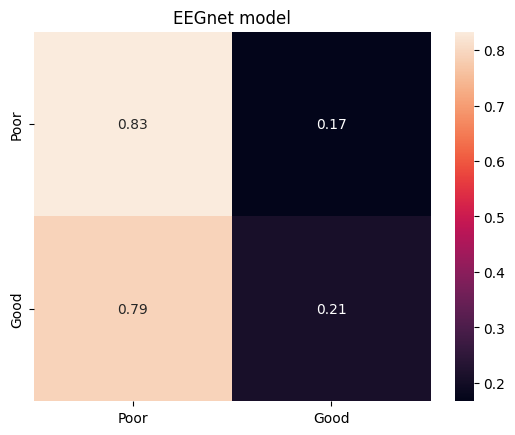

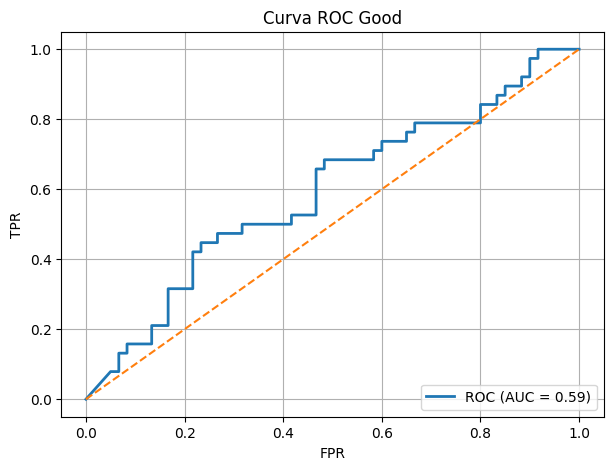

In [ ]:
# evaluated the model after training
y_pred= grid_clf.predict(X_val)
report = classification_report(Y_val, y_pred,target_names=["Poor Outcome", "Good Outcome"])
confusion = confusion_matrix(Y_val, y_pred,normalize="true")
print(report)
plt.figure()
heatmap(confusion, annot=True, fmt=".2g",
        xticklabels=S_labels,
        yticklabels=S_labels)


plt.title(f"EEGnet model")
plt.show()


y_score = grid_clf.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(Y_val, y_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2,
            label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Curva ROC {S_labels[1]}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Foundational Labram

In [ ]:
try: 
    del model 
except:
    pass

class MyLabram(torch.nn.Module):

    def __init__(self, n_times, n_chans, n_outputs, sfreq, ch_names,
        patch_size=256, embed_dim = 128, num_layers=12, num_heads=6, mlp_ratio=4, drop_prob = 0.1,
        attn_drop_prob = 0.1, activation =torch.nn.GELU):
        super().__init__()

        self.ch_names = ch_names

        self.model = Labram( n_times=n_times, n_chans=n_chans, n_outputs=n_outputs, num_layers=num_layers, sfreq=sfreq,
            num_heads=num_heads, patch_size=patch_size, embed_dim=embed_dim, mlp_ratio=mlp_ratio, drop_prob=drop_prob,
            attn_drop_prob=attn_drop_prob, activation=activation)

    def forward(self, x):
        return self.model(x, ch_names=self.ch_names)

model = MyLabram(
    n_times=n_times,
    n_chans=n_chans,
    n_outputs=len(outputs),
    ch_names=channels,
    sfreq=128
)

lr = np.linspace(0.001, 0.1, 2)
weight_decay = np.linspace(0.00001, 0.001, 2)
batch_size = 8
n_epochs = 2

parameters={"optimizer__lr":lr, "optimizer__weight_decay":weight_decay, "module__drop_prob":np.linspace(0.1, 0.4, 2), "module__ch_names": [channels],
            "module__n_times": [n_times], "module__n_chans":[n_chans], "module__n_outputs":[len(outputs)], "module__sfreq":[128]}


clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "roc_auc",
        "f1",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    classes=outputs,
    max_epochs=n_epochs,
    verbose=2,
)

grid_clf=RandomizedSearchCV(clf, parameters, n_iter=20, refit=True, cv=cv_patients(patients_train, n_split=3), scoring="roc_auc", verbose=1)

grid_clf.fit(X, Y)






# evaluated the model after training
y_pred= grid_clf.predict(X_val)
report = classification_report(Y_val, y_pred,target_names=["Poor Outcome", "Good Outcome"])
confusion = confusion_matrix(Y_val, y_pred,normalize="true")
print(report)
plt.figure()
heatmap(confusion, annot=True, fmt=".2g",
        xticklabels=S_labels,
        yticklabels=S_labels)


plt.title(f"EEGnet model")
plt.show()


y_score = grid_clf.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(Y_val, y_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2,
            label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Curva ROC {S_labels[1]}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Fitting 5 folds for each of 8 candidates, totalling 40 fits
  epoch    train_f1    train_loss    train_roc_auc      lr       dur
-------  ----------  ------------  ---------------  ------  --------
      1      0.5673        0.6918           0.3733  0.0010  711.7089


## Foundational CbraMod

In [ ]:
try: 
    del model 
except:
    pass

model = CBraMod(n_times=n_times-40, n_chans=n_chans, n_outputs=len(outputs))
model.cuda()

lr = np.linspace(0.001, 0.1, 2)
weight_decay = np.linspace(0.00001, 0.001, 2)
batch_size = 8
n_epochs = 2

parameters={"optimizer__lr":lr, "optimizer__weight_decay":weight_decay, "module__drop_prob":np.linspace(0.1, 0.4, 2),
            "module__n_times": [n_times], "module__n_chans":[n_chans], "module__n_outputs":[len(outputs)]}


clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "roc_auc",
        "f1",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    classes=outputs,
    max_epochs=n_epochs,
    verbose=2,
)

grid_clf=GridSearchCV(clf, parameters, refit=True, cv=cv_patients(patients_train, n_split=3), scoring="roc_auc", verbose=1)
grid_clf.fit(X, Y)






# evaluated the model after training
y_pred= grid_clf.predict(X_val)
report = classification_report(Y_val, y_pred,target_names=["Poor Outcome", "Good Outcome"])
confusion = confusion_matrix(Y_val, y_pred,normalize="true")
print(report)
plt.figure()
heatmap(confusion, annot=True, fmt=".2g",
        xticklabels=S_labels,
        yticklabels=S_labels)


plt.title(f"EEGnet model")
plt.show()


y_score = grid_clf.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(Y_val, y_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2,
            label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Curva ROC {S_labels[1]}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Foundational EEGPT

In [ ]:
try: 
    del model 
except:
    pass

model = EEGPT(n_times=n_times, n_chans=n_chans, n_outputs=len(outputs), patch_size=256,patch_stride=64)
model.cuda()

lr = np.linspace(0.001, 0.1, 2)
weight_decay = np.linspace(0.00001, 0.001, 2)
batch_size = 8
n_epochs = 2

parameters={"optimizer__lr":lr, "optimizer__weight_decay":weight_decay, "module__drop_prob":np.linspace(0.1, 0.4, 2),
            "module__n_times": [n_times], "module__n_chans":[n_chans], "module__n_outputs":[len(outputs)]}


clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "roc_auc",
        "f1",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    classes=outputs,
    max_epochs=n_epochs,
    verbose=2,
)

grid_clf=GridSearchCV(clf, parameters, refit=True, cv=cv_patients(patients_train, n_split=3), scoring="roc_auc", verbose=1)
grid_clf.fit(X, Y)






# evaluated the model after training
y_pred= grid_clf.predict(X_val)
report = classification_report(Y_val, y_pred,target_names=["Poor Outcome", "Good Outcome"])
confusion = confusion_matrix(Y_val, y_pred,normalize="true")
print(report)
plt.figure()
heatmap(confusion, annot=True, fmt=".2g",
        xticklabels=S_labels,
        yticklabels=S_labels)


plt.title(f"EEGnet model")
plt.show()


y_score = grid_clf.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(Y_val, y_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2,
            label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Curva ROC {S_labels[1]}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Fitting 5 folds for each of 8 candidates, totalling 40 fits


## Foundational BENDR

In [ ]:
try: 
    del model 
except:
    pass

model = BENDR(n_times=n_times, n_chans=n_chans, n_outputs=len(outputs), contextualizer_hidden=1024, transformer_layers=4, transformer_heads=4)
model.cuda()

lr = 6e-6
weight_decay = 1e-7
batch_size = 8
n_epochs = 2

parameters={"optimizer__lr":lr, "optimizer__weight_decay":weight_decay, "module__drop_prob":np.linspace(0.1, 0.4, 2),
            "module__n_times": [n_times], "module__n_chans":[n_chans], "module__n_outputs":[len(outputs)]}


clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    train_split=None,
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    callbacks=[
        "roc_auc",
        "f1",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    classes=outputs,
    max_epochs=n_epochs,
    verbose=2,
)

grid_clf=GridSearchCV(clf, parameters, refit=True, cv=cv_patients(patients_train, n_split=3), scoring="roc_auc", verbose=1, error_score='raise')
grid_clf.fit(X, Y)






# evaluated the model after training
y_pred= grid_clf.predict(X_val)
report = classification_report(Y_val, y_pred,target_names=["Poor Outcome", "Good Outcome"])
confusion = confusion_matrix(Y_val, y_pred,normalize="true")
print(report)
plt.figure()
heatmap(confusion, annot=True, fmt=".2g",
        xticklabels=S_labels,
        yticklabels=S_labels)


plt.title(f"EEGnet model")
plt.show()


y_score = grid_clf.predict_proba(X_val)
fpr, tpr, thresholds = roc_curve(Y_val, y_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2,
            label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'Curva ROC {S_labels[1]}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

  epoch    train_f1    train_loss    train_roc_auc      lr       dur
-------  ----------  ------------  ---------------  ------  --------
      1      0.0000        0.7018           0.6074  0.0000  435.6649


NotFittedError: This GridSearchCV instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from Utils.labram_optuna_search import load_labram_data, run_optuna_search

# Ejemplo rápido de búsqueda con Optuna para Labram
X, y, demograp_data = load_labram_data(hours=(36, 40, 44))
study, best_params = run_optuna_search(
    X,
    y,
    demograp_data,
    n_trials=5,
    n_jobs=1,
    study_name="labram_optuna_demo",
)
print(best_params)
